In [4]:
import boto3
import os

# Create S3 client
s3 = boto3.client(
    's3',
    endpoint_url='https://data.source.coop',
    aws_access_key_id='',
    aws_secret_access_key=''
)

bucket = 'nasa'
prefix = 'marine-debris/labels/'  # where your .geojson files are
local_dir = 'labels'

# Make local folder
os.makedirs(local_dir, exist_ok=True)

# List and download all label files
response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix)
for obj in response.get('Contents', []):
    key = obj['Key']
    filename = os.path.join(local_dir, os.path.basename(key))
    print(f"Downloading {key} → {filename}")
    s3.download_file(bucket, key, filename)


ClientError: An error occurred (403) when calling the ListObjectsV2 operation: Forbidden

In [9]:
prefix = "marine-debris/images/"
response = s3.list_objects_v2(Bucket=bucket, Prefix=prefix, MaxKeys=5)

for obj in response.get("Contents", []):
    key = obj["Key"]
    print("Found:", key)
    s3.download_file(bucket, key, key.split("/")[-1])  # saves locally


ClientError: An error occurred (403) when calling the ListObjectsV2 operation: Forbidden

In [8]:
import os
print(os.getcwd())


c:\Users\nayee\OneDrive\Desktop\python\marine debris


Takes NASA’s raw format (.npy satellite images + .geojson bounding boxes)

Converts .npy → .jpg

Reads .geojson and converts bounding boxes into YOLO label format

Stores them neatly in /images/nasa and /labels/nasa

Takes your RoboFlow dataset (already YOLO format)

Copies it into /images/roboflow and /labels/roboflow inside the merged dataset

Takes your SeaClear dataset (already YOLO format)

Copies it into /images/seaclear and /labels/seaclear inside the merged dataset

Outputs one clean, unified YOLO dataset (final_dataset/)

Every image + label across all 3 datasets is in the same format

Ready to train in YOLOv5, YOLOv8, or similar

Basically, this code is data preprocessing + dataset merging so you can train one model with satellite + drone + underwater images all together.

If you skip this step, NASA’s data stays in a w

In [25]:
import os
import json
import shutil
import numpy as np
from PIL import Image
from glob import glob
from tqdm import tqdm

# =============================
# CONFIGURE YOUR PATHS
# =============================
NASA_DATA_DIR = r"C:\Users\nayee\OneDrive\Desktop\python\marine debris"
ROBOFLOW_DIR = r"C:\Users\nayee\Downloads\roboflow data"
SEACLEAR_DIR = r"C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo"
OUTPUT_DIR = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset"

# Classes mapping (edit if needed)
CLASSES = ["plastic", "algae", "sargassum", "wood", "other"]

# =============================
# HELPER FUNCTIONS
# =============================
def convert_geojson_to_yolo(geojson_path, img_width, img_height):
    """Convert geojson bounding boxes to YOLO format."""
    with open(geojson_path, 'r') as f:
        data = json.load(f)

    yolo_labels = []
    for feature in data.get("features", []):
        props = feature.get("properties", {})
        cls_name = props.get("class", "other").lower()
        if cls_name not in CLASSES:
            cls_name = "other"
        cls_id = CLASSES.index(cls_name)

        # bbox in geojson: [min_lon, min_lat, max_lon, max_lat] (pixel coords expected)
        coords = feature["geometry"]["coordinates"][0]
        xs = [p[0] for p in coords]
        ys = [p[1] for p in coords]
        xmin, xmax = min(xs), max(xs)
        ymin, ymax = min(ys), max(ys)

        # Convert to YOLO (normalized)
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        box_width = (xmax - xmin) / img_width
        box_height = (ymax - ymin) / img_height

        yolo_labels.append(f"{cls_id} {x_center} {y_center} {box_width} {box_height}")

    return yolo_labels


def process_nasa_dataset():
    """Convert NASA npy+geojson to YOLO and save in OUTPUT_DIR."""
    print("Processing NASA dataset...")
    nasa_img_dir = os.path.join(OUTPUT_DIR, "images", "nasa")
    nasa_lbl_dir = os.path.join(OUTPUT_DIR, "labels", "nasa")
    os.makedirs(nasa_img_dir, exist_ok=True)
    os.makedirs(nasa_lbl_dir, exist_ok=True)

    geojson_files = glob(os.path.join(NASA_DATA_DIR, "labels", "*.geojson"))

    for gj_path in tqdm(geojson_files):
        base_name = os.path.splitext(os.path.basename(gj_path))[0]
        npy_path = gj_path.replace(".geojson", ".npy")

        if not os.path.exists(npy_path):
            continue

        # Load npy image
        img_array = np.load(npy_path)
        img = Image.fromarray(img_array.astype(np.uint8))
        img_width, img_height = img.size

        # Save image as JPG
        img_out_path = os.path.join(nasa_img_dir, base_name + ".jpg")
        img.save(img_out_path)

        # Convert labels
        yolo_labels = convert_geojson_to_yolo(gj_path, img_width, img_height)
        lbl_out_path = os.path.join(nasa_lbl_dir, base_name + ".txt")
        with open(lbl_out_path, "w") as f:
            f.write("\n".join(yolo_labels))


def merge_yolo_datasets(src_dir, name):
    """Copy existing YOLO dataset into OUTPUT_DIR/images/name and OUTPUT_DIR/labels/name."""
    img_out_dir = os.path.join(OUTPUT_DIR, "images", name)
    lbl_out_dir = os.path.join(OUTPUT_DIR, "labels", name)
    os.makedirs(img_out_dir, exist_ok=True)
    os.makedirs(lbl_out_dir, exist_ok=True)

    img_files = glob(os.path.join(src_dir, "**", "images", "**", "*.*"), recursive=True)
    lbl_files = glob(os.path.join(src_dir, "**", "labels", "**", "*.txt"), recursive=True)

    for img in tqdm(img_files, desc=f"Merging images from {name}"):
        shutil.copy(img, img_out_dir)

    for lbl in tqdm(lbl_files, desc=f"Merging labels from {name}"):
        shutil.copy(lbl, lbl_out_dir)


# =============================
# MAIN
# =============================
if __name__ == "__main__":
    # 1. Process NASA
    process_nasa_dataset()

    # 2. Merge RoboFlow
    merge_yolo_datasets(ROBOFLOW_DIR, "roboflow")

    # 3. Merge SeaClear
    merge_yolo_datasets(SEACLEAR_DIR, "seaclear")

    print(f"✅ All datasets merged into: {OUTPUT_DIR}")
    print("Now you can create a data.yaml for YOLO training.")


Processing NASA dataset...


Merging labels from roboflow: 100%|██████████| 1725/1725 [00:07<00:00, 221.99it/s]
Merging images from seaclear: 0it [00:00, ?it/s]
Merging labels from seaclear: 0it [00:00, ?it/s]

✅ All datasets merged into: C:\Users\nayee\OneDrive\Desktop\python\final_dataset
Now you can create a data.yaml for YOLO training.


In [10]:
import json
import os
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# === CONFIGURATION ===
SEACLEAR_DIR = r"C:\Users\nayee\Downloads\sea clear data\Seaclear Marine Debris Dataset"
OUTPUT_DIR = r"C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo"
TRAIN_SPLIT = 0.8  # 80% train / 20% val

# Paths
JSON_PATH = os.path.join(SEACLEAR_DIR, "dataset.json")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Create YOLO folders
for split in ["train", "val"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "labels"), exist_ok=True)

# === Load COCO annotations ===
with open(JSON_PATH, "r") as f:
    coco = json.load(f)

images_info = {img["id"]: img for img in coco["images"]}

# Map category IDs to YOLO IDs (0-based)
cat_id_to_yolo = {cat["id"]: idx for idx, cat in enumerate(coco["categories"])}

# Group annotations by image
image_annotations = {}
for ann in coco["annotations"]:
    img_id = ann["image_id"]
    if img_id not in image_annotations:
        image_annotations[img_id] = []
    image_annotations[img_id].append(ann)

# === Prepare train/val split ===
all_image_ids = list(images_info.keys())
train_ids, val_ids = train_test_split(all_image_ids, train_size=TRAIN_SPLIT, random_state=42)

def process_images(ids_list, split):
    for img_id in tqdm(ids_list, desc=f"Processing {split}"):
        img_info = images_info[img_id]
        file_name = img_info["file_name"]  # relative path
        img_w, img_h = img_info["width"], img_info["height"]

        # Find source image
        src_img_path = os.path.join(SEACLEAR_DIR, file_name)
        if not os.path.exists(src_img_path):
            continue  # skip if missing

        # Destination paths
        dst_img_path = os.path.join(OUTPUT_DIR, split, "images", os.path.basename(file_name))
        dst_label_path = os.path.join(OUTPUT_DIR, split, "labels", os.path.splitext(os.path.basename(file_name))[0] + ".txt")

        # Copy image
        shutil.copy2(src_img_path, dst_img_path)

        # Write YOLO labels
        with open(dst_label_path, "w") as label_file:
            if img_id in image_annotations:
                for ann in image_annotations[img_id]:
                    cat_id = ann["category_id"]
                    yolo_id = cat_id_to_yolo[cat_id]
                    x, y, w, h = ann["bbox"]  # COCO format
                    # Convert to YOLO format
                    x_center = (x + w / 2) / img_w
                    y_center = (y + h / 2) / img_h
                    w_norm = w / img_w
                    h_norm = h / img_h
                    label_file.write(f"{yolo_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

# Process train and val sets
process_images(train_ids, "train")
process_images(val_ids, "val")

print(f"✅ Conversion complete! YOLO dataset saved to: {OUTPUT_DIR}")


Processing val: 100%|██████████| 1722/1722 [00:00<00:00, 49202.90it/s]

✅ Conversion complete! YOLO dataset saved to: C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo


In [22]:
merge_yolo_datasets(r"C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo", "seaclear")


Merging seaclear dataset...


Merging images from seaclear: 0it [00:00, ?it/s]
Merging labels from seaclear: 0it [00:00, ?it/s]


In [27]:
if __name__ == "__main__":
    # 1. Process NASA
    process_nasa_dataset()

    # 2. Merge RoboFlow
    merge_yolo_datasets(ROBOFLOW_DIR, "roboflow")

    # 3. Merge SeaClear train and val separately
    merge_yolo_datasets(r"C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo\train", "seaclear")
    merge_yolo_datasets(r"C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo\val", "seaclear")


    print(f"✅ All datasets merged into: {OUTPUT_DIR}")
    print("Now you can create a data.yaml for YOLO training.")


Processing NASA dataset...


Merging labels from roboflow: 100%|██████████| 1725/1725 [00:01<00:00, 1083.29it/s]
Merging images from seaclear: 0it [00:00, ?it/s]
Merging labels from seaclear: 0it [00:00, ?it/s]
Merging images from seaclear: 0it [00:00, ?it/s]
Merging labels from seaclear: 0it [00:00, ?it/s]

✅ All datasets merged into: C:\Users\nayee\OneDrive\Desktop\python\final_dataset
Now you can create a data.yaml for YOLO training.


In [28]:
def merge_yolo_datasets(src_dir, name):
    img_out_dir = os.path.join(OUTPUT_DIR, "images", name)
    lbl_out_dir = os.path.join(OUTPUT_DIR, "labels", name)
    os.makedirs(img_out_dir, exist_ok=True)
    os.makedirs(lbl_out_dir, exist_ok=True)

    # Find all images recursively in the src_dir (any folder)
    img_files = glob(os.path.join(src_dir, "**", "*.*"), recursive=True)
    img_files = [f for f in img_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Copy images
    for img in tqdm(img_files, desc=f"Merging images from {name}"):
        shutil.copy(img, img_out_dir)

    # If you have labels for SeaClear in YOLO txt format in same folder or subfolders, uncomment this and adjust:
    # lbl_files = glob(os.path.join(src_dir, "**", "*.txt"), recursive=True)
    # for lbl in tqdm(lbl_files, desc=f"Merging labels from {name}"):
    #     shutil.copy(lbl, lbl_out_dir)


In [29]:
import os
import shutil
from glob import glob
from tqdm import tqdm

def merge_yolo_datasets(src_dir, name):
    """Copy existing YOLO dataset images and labels from src_dir (recursive) into final dataset."""
    img_out_dir = os.path.join(OUTPUT_DIR, "images", name)
    lbl_out_dir = os.path.join(OUTPUT_DIR, "labels", name)
    os.makedirs(img_out_dir, exist_ok=True)
    os.makedirs(lbl_out_dir, exist_ok=True)

    # Recursively find all image files (jpg, jpeg, png)
    img_files = glob(os.path.join(src_dir, "**", "*.*"), recursive=True)
    img_files = [f for f in img_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Recursively find all label files (*.txt)
    lbl_files = glob(os.path.join(src_dir, "**", "*.txt"), recursive=True)

    for img in tqdm(img_files, desc=f"Merging images from {name}"):
        shutil.copy(img, img_out_dir)

    for lbl in tqdm(lbl_files, desc=f"Merging labels from {name}"):
        shutil.copy(lbl, lbl_out_dir)


In [36]:
import json
import os
import shutil
from tqdm import tqdm
from sklearn.model_selection import train_test_split

# === CONFIGURATION ===
SEACLEAR_DIR = r"C:\Users\nayee\Downloads\sea clear data\Seaclear Marine Debris Dataset"
OUTPUT_DIR = r"C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo"
TRAIN_SPLIT = 0.8  # 80% train / 20% val

# Paths
JSON_PATH = os.path.join(SEACLEAR_DIR, "dataset.json")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Create YOLO folders for train and val splits
for split in ["train", "val"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, "labels"), exist_ok=True)

# === Load COCO annotations ===
with open(JSON_PATH, "r") as f:
    coco = json.load(f)

images_info = {img["id"]: img for img in coco["images"]}

# Map category IDs to YOLO IDs (0-based)
cat_id_to_yolo = {cat["id"]: idx for idx, cat in enumerate(coco["categories"])}

# Group annotations by image
image_annotations = {}
for ann in coco["annotations"]:
    img_id = ann["image_id"]
    if img_id not in image_annotations:
        image_annotations[img_id] = []
    image_annotations[img_id].append(ann)

# === Prepare train/val split ===
all_image_ids = list(images_info.keys())
train_ids, val_ids = train_test_split(all_image_ids, train_size=TRAIN_SPLIT, random_state=42)

def process_images(ids_list, split):
    for img_id in tqdm(ids_list, desc=f"Processing {split}"):
        img_info = images_info[img_id]
        file_name = img_info["file_name"]  # relative path with nested folders
        img_w, img_h = img_info["width"], img_info["height"]

        # Correctly join base directory with nested subfolders and image filename
        src_img_path = os.path.join(SEACLEAR_DIR, *file_name.split('/'))

        if not os.path.exists(src_img_path):
            # Try to search image recursively inside SEACLEAR_DIR
            found = False
            for root, dirs, files in os.walk(SEACLEAR_DIR):
                if os.path.basename(file_name) in files:
                    src_img_path = os.path.join(root, os.path.basename(file_name))
                    found = True
                    break
            if not found:
                print(f"Missing image: {os.path.join(SEACLEAR_DIR, file_name)}")
                continue  # <--- valid here inside the for-loop

        # Destination paths for images and labels
        dst_img_path = os.path.join(OUTPUT_DIR, split, "images", os.path.basename(file_name))
        dst_label_path = os.path.join(OUTPUT_DIR, split, "labels", os.path.splitext(os.path.basename(file_name))[0] + ".txt")

        # Copy image
        shutil.copy2(src_img_path, dst_img_path)

        # Write YOLO labels in text file
        with open(dst_label_path, "w") as label_file:
            if img_id in image_annotations:
                for ann in image_annotations[img_id]:
                    cat_id = ann["category_id"]
                    yolo_id = cat_id_to_yolo[cat_id]
                    x, y, w, h = ann["bbox"]  # COCO format: [top-left x, y, width, height]
                    # Convert bbox to YOLO format (normalized center x,y and width,height)
                    x_center = (x + w / 2) / img_w
                    y_center = (y + h / 2) / img_h
                    w_norm = w / img_w
                    h_norm = h / img_h
                    label_file.write(f"{yolo_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

# Process train and val splits
process_images(train_ids, "train")
process_images(val_ids, "val")

print(f"✅ Conversion complete! YOLO dataset saved to: {OUTPUT_DIR}")


Processing val: 100%|██████████| 1722/1722 [00:36<00:00, 47.67it/s]

✅ Conversion complete! YOLO dataset saved to: C:\Users\nayee\OneDrive\Desktop\python\seaclear_yolo


In [3]:
import os
import shutil

# Paths for source datasets
NASA_IMAGES = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\images\nasa"
NASA_LABELS = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\labels\nasa"

ROBOFLOW_IMAGES = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\images\roboflow"
ROBOFLOW_LABELS = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\labels\roboflow"

SEACLEAR_TRAIN_IMAGES = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\seaclear_train\images"
SEACLEAR_TRAIN_LABELS = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\seaclear_train\labels"

SEACLEAR_VAL_IMAGES = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\seaclear_val\images"
SEACLEAR_VAL_LABELS = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset\seaclear_val\labels"

# Output folders
OUTPUT_ROOT = r"C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split"
TRAIN_IMAGES_OUT = os.path.join(OUTPUT_ROOT, "train", "images")
TRAIN_LABELS_OUT = os.path.join(OUTPUT_ROOT, "train", "labels")
VAL_IMAGES_OUT = os.path.join(OUTPUT_ROOT, "val", "images")
VAL_LABELS_OUT = os.path.join(OUTPUT_ROOT, "val", "labels")

# Create output dirs if not exist
for folder in [TRAIN_IMAGES_OUT, TRAIN_LABELS_OUT, VAL_IMAGES_OUT, VAL_LABELS_OUT]:
    os.makedirs(folder, exist_ok=True)

def copy_files(src_img_dir, src_lbl_dir, dst_img_dir, dst_lbl_dir):
    for filename in os.listdir(src_img_dir):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Copy image
            shutil.copy2(os.path.join(src_img_dir, filename), os.path.join(dst_img_dir, filename))
            # Copy label if exists
            label_name = os.path.splitext(filename)[0] + ".txt"
            label_path = os.path.join(src_lbl_dir, label_name)
            if os.path.exists(label_path):
                shutil.copy2(label_path, os.path.join(dst_lbl_dir, label_name))
            else:
                print(f"Warning: Label file not found for image {filename}")

# Copy train data: nasa + roboflow + seaclear_train
copy_files(NASA_IMAGES, NASA_LABELS, TRAIN_IMAGES_OUT, TRAIN_LABELS_OUT)
copy_files(ROBOFLOW_IMAGES, ROBOFLOW_LABELS, TRAIN_IMAGES_OUT, TRAIN_LABELS_OUT)
copy_files(SEACLEAR_TRAIN_IMAGES, SEACLEAR_TRAIN_LABELS, TRAIN_IMAGES_OUT, TRAIN_LABELS_OUT)

# Copy val data: seaclear_val
copy_files(SEACLEAR_VAL_IMAGES, SEACLEAR_VAL_LABELS, VAL_IMAGES_OUT, VAL_LABELS_OUT)

print("✅ Merging complete!")


✅ Merging complete!


In [ ]:
from ultralytics import YOLO

def train_yolo():
    # Load a pre-trained YOLOv8 nano model
    model = YOLO('yolov8n.pt')  

    # Train the model using your dataset config file
    model.train(
        data = "C:\\Users\\nayee\\OneDrive\\Desktop\\python\\final_dataset_split\\data.yaml",
        epochs=25,           # number of epochs to train
        imgsz=640,           # image size (YOLO input size)
        batch=10,            # batch size (adjust based on your GPU)
        device='cpu'           # GPU device 0; use 'cpu' if no GPU
    )

if __name__ == '__main__':
    train_yolo()


New https://pypi.org/project/ultralytics/8.3.177 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.176  Python-3.10.1 torch-2.1.2+cpu CPU (13th Gen Intel Core(TM) i7-13620H)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train

train: Scanning C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\train\labels.cache... 8613 images, 856 backgrounds, 6546 corrupt: 100%|██████████| 9966/9966 [00:00<?, ?it/s]

train: C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\train\images\100.jpg: ignoring corrupt image/label: Label class 6 exceeds dataset class count 5. Possible class labels are 0-4
train: C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\train\images\1000.jpg: ignoring corrupt image/label: Label class 8 exceeds dataset class count 5. Possible class labels are 0-4
train: C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\train\images\1001.jpg: ignoring corrupt image/label: Label class 8 exceeds dataset class count 5. Possible class labels are 0-4
train: C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\train\images\1002.jpg: ignoring corrupt image/label: Label class 8 exceeds dataset class count 5. Possible class labels are 0-4
train: C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\train\images\1003.jpg: ignoring corrupt image/label: Label class 8 exceeds dataset class count 5. Possible class labels are 0-4
train: C:\Users\nayee\OneDrive\

val: Fast image access  (ping: 0.10.0 ms, read: 590.5289.6 MB/s, size: 192.1 KB)


val: Scanning C:\Users\nayee\OneDrive\Desktop\python\final_dataset_split\val\labels.cache... 1722 images, 0 backgrounds, 1534 corrupt: 100%|██████████| 1722/1722 [00:00<?, ?it/s]

...

optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.00046875), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to C:\Users\nayee\runs\detect\train2
Starting training for 25 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       1/25         0G      1.778      2.802      1.274         95        640: 100%|██████████| 342/342 [1:09:05<00:00, 12.12s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:53<00:00,  5.39s/it]

                   all        188        234      0.432      0.333      0.376      0.246



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


       2/25         0G      1.713      2.118      1.253         70        640:  86%|████████▌ | 293/342 [1:06:35<12:17, 15.05s/it] 

In [2]:
import os
import json

# Paths
geojson_dir = "labels"       # where your .geojson files are
yolo_labels_dir = "yolo_labels"
os.makedirs(yolo_labels_dir, exist_ok=True)

# Class mapping (add more if needed)
CLASS_MAP = {"marine_debris": 0}

# Assume all images are same size (adjust if not)
IMG_W, IMG_H = 1024, 1024  # 🔹 update if your images have different resolution

for file in os.listdir(geojson_dir):
    if file.endswith(".geojson"):
        geojson_path = os.path.join(geojson_dir, file)
        txt_filename = os.path.splitext(file)[0] + ".txt"
        txt_path = os.path.join(yolo_labels_dir, txt_filename)

        with open(geojson_path, "r") as f:
            data = json.load(f)

        with open(txt_path, "w") as out:
            for feature in data["features"]:
                cls_name = feature["properties"].get("label", "marine_debris")
                cls_id = CLASS_MAP.get(cls_name, 0)

                # Extract coordinates from geometry
                geom = feature["geometry"]
                if geom["type"] == "Polygon":
                    coords = geom["coordinates"][0]  # first polygon ring
                    xs = [pt[0] for pt in coords]
                    ys = [pt[1] for pt in coords]

                    xmin, xmax = min(xs), max(xs)
                    ymin, ymax = min(ys), max(ys)

                elif geom["type"] == "Point":
                    x, y = geom["coordinates"]
                    xmin, xmax = x - 10, x + 10   # small box around point
                    ymin, ymax = y - 10, y + 10

                else:
                    continue  # skip unsupported types

                # Convert to YOLO format (normalize)
                x_center = (xmin + xmax) / 2 / IMG_W
                y_center = (ymin + ymax) / 2 / IMG_H
                w = (xmax - xmin) / IMG_W
                h = (ymax - ymin) / IMG_H

                out.write(f"{cls_id} {x_center} {y_center} {w} {h}\n")

print("✅ Conversion complete. YOLO labels saved in:", yolo_labels_dir)


✅ Conversion complete. YOLO labels saved in: yolo_labels


In [13]:
!aws s3 ls s3://nasa/marine-debris/ --endpoint-url=https://data.source.coop

Unable to locate credentials. You can configure credentials by running "aws configure".


In [14]:
!aws s3 sync s3://nasa/marine-debris/ . --endpoint-url=https://data.source.coop

fatal error: Unable to locate credentials


In [16]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config
import os

# Anonymous S3 client
s3 = boto3.client(
    "s3",
    endpoint_url="https://data.source.coop",
    config=Config(signature_version=UNSIGNED)
)

bucket = "nasa"
prefix = "marine-debris/images/"
local_dir = "satellite_images"
os.makedirs(local_dir, exist_ok=True)

# Use paginator to safely list objects
paginator = s3.get_paginator('list_objects_v2')
for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
    for obj in page.get('Contents', []):
        key = obj['Key']
        if key.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff')):
            filename = os.path.join(local_dir, os.path.basename(key))
            print(f"Downloading {key} → {filename}")
            s3.download_file(bucket, key, filename)

print("✅ All images downloaded to", local_dir)


✅ All images downloaded to satellite_images


In [19]:
import json
import os
import boto3
from botocore import UNSIGNED
from botocore.config import Config

# S3 client (anonymous)
s3 = boto3.client(
    "s3",
    endpoint_url="https://data.source.coop",
    config=Config(signature_version=UNSIGNED)
)

bucket = "nasa"
prefix = "marine-debris/images/"
local_dir = "satellite_images"
os.makedirs(local_dir, exist_ok=True)

# Load geojson
with open("C:\\Users\\nayee\\OneDrive\\Desktop\\python\\marine debris\\labels\\20180313_154259_1008_17023-29730-16.geojson") as f:
    data = json.load(f)

# Extract all labels (image identifiers)
image_labels = set()
for feature in data["features"]:
    label = feature["properties"]["label"]
    image_labels.add(label)

# Download images
for label in image_labels:
    key = f"marine-debris/images/{label}.tif"
    local_path = os.path.join(local_dir, f"{label}.tif")
    try:
        s3.download_file(bucket, key, local_path)
        print("Downloaded:", local_path)
    except Exception as e:
        print("Failed to download:", key, e)

print("✅ Done downloading all labeled images.")


Failed to download: marine-debris/images/shapefile85763_20180313_154259_1008.tif An error occurred (403) when calling the HeadObject operation: Forbidden
Failed to download: marine-debris/images/shapefile85764_20180313_154259_1008.tif An error occurred (403) when calling the HeadObject operation: Forbidden
✅ Done downloading all labeled images.


In [9]:
import rasterio
import numpy as np
from PIL import Image
import os, glob

input_dir = "MARIDA/images"
output_dir = "MARIDA/images_jpg"
os.makedirs(output_dir, exist_ok=True)

for tif_file in glob.glob(os.path.join(input_dir, "*.tif")):
    with rasterio.open(tif_file) as src:
        arr = src.read(1).astype(float)  # read as float to handle NaN

        # Replace NaN with 0
        arr = np.nan_to_num(arr, nan=0.0)

        # Normalize safely to 0–255
        if arr.max() > arr.min():  # avoid divide by zero
            arr = 255 * (arr - arr.min()) / (arr.max() - arr.min())
        else:
            arr = np.zeros_like(arr)

        arr = arr.astype(np.uint8)

        # Make it 3-channel (RGB-like for YOLO)
        rgb = np.stack([arr, arr, arr], axis=-1)

        out_name = os.path.splitext(os.path.basename(tif_file))[0] + ".jpg"
        Image.fromarray(rgb).save(os.path.join(output_dir, out_name))


In [14]:
import json, os

# paths
images_dir = "MARIDA/images_jpg"
labels_file = "MARIDA/labels_mapping.txt"   # <-- use the correct name
output_labels_file = "MARIDA/labels_mapping_jpg.txt"

# load mapping
with open(labels_file, "r") as f:
    labels = json.load(f)   # now labels is a dict

# update mapping keys from .tif → .jpg
updated_labels = {}
for k, v in labels.items():
    jpg_name = k.replace(".tif", ".jpg")
    if os.path.exists(os.path.join(images_dir, jpg_name)):
        updated_labels[jpg_name] = v

# save new mapping
with open(output_labels_file, "w") as f:
    json.dump(updated_labels, f, indent=4)

print(f"✅ Updated label mapping saved: {output_labels_file}")


✅ Updated label mapping saved: MARIDA/labels_mapping_jpg.txt


In [15]:
import os, json, random, shutil

# paths
images_dir = "MARIDA/images_jpg"
labels_file = "MARIDA/labels_mapping_jpg.txt"
output_base = "final_dataset_split"   # new dataset folder

# create folder structure
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_base, "images", split), exist_ok=True)
    os.makedirs(os.path.join(output_base, "labels", split), exist_ok=True)

# load updated labels
with open(labels_file, "r") as f:
    labels = json.load(f)

# shuffle images
all_images = list(labels.keys())
random.shuffle(all_images)

# split sizes
n = len(all_images)
train_split = int(0.7 * n)
val_split = int(0.9 * n)

splits = {
    "train": all_images[:train_split],
    "val": all_images[train_split:val_split],
    "test": all_images[val_split:]
}

# copy images + create label .txt
for split, files in splits.items():
    for img_name in files:
        # copy image
        shutil.copy(
            os.path.join(images_dir, img_name),
            os.path.join(output_base, "images", split, img_name)
        )
        # save label as txt (classification version: just one line with vector)
        label_txt = os.path.splitext(img_name)[0] + ".txt"
        with open(os.path.join(output_base, "labels", split, label_txt), "w") as f:
            f.write(" ".join(map(str, labels[img_name])))


In [23]:
import os, json

images_dir = "MARIDA/images_jpg"
labels_out_dir = "MARIDA/labels"
mapping_file = "MARIDA/labels_mapping.txt"

os.makedirs(labels_out_dir, exist_ok=True)

# Load mapping (assuming it's JSON format)
with open(mapping_file, "r") as f:
    mapping = json.load(f)

# Loop over entries in mapping
for img_name, annotations in mapping.items():
    label_file = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join(labels_out_dir, label_file)

    with open(label_path, "w") as lf:
        for ann in annotations:
            cls = ann["class_id"]       # YOLO class index
            x_center = ann["x_center"]  # normalized [0,1]
            y_center = ann["y_center"]
            w = ann["width"]
            h = ann["height"]
            lf.write(f"{cls} {x_center} {y_center} {w} {h}\n")

print("✅ YOLO .txt labels generated in MARIDA/labels")


TypeError: 'int' object is not subscriptable

In [24]:
import os, json

# paths
images_dir = "MARIDA/images_jpg"
mapping_file = "MARIDA/labels_mapping_jpg.txt"
labels_out_dir = "MARIDA/labels"

os.makedirs(labels_out_dir, exist_ok=True)

# load mapping
with open(mapping_file, "r") as f:
    mapping = json.load(f)

# loop over images and create YOLO .txt labels
for img_name, label_vector in mapping.items():
    # convert filename to match jpg
    jpg_name = img_name.replace(".tif", ".jpg")
    label_file = os.path.join(labels_out_dir, jpg_name.replace(".jpg", ".txt"))

    with open(label_file, "w") as lf:
        for class_id, val in enumerate(label_vector):
            if val == 1:
                # YOLO expects: class x_center y_center width height
                # But here you only have class presence → so just write class_id
                lf.write(f"{class_id} 0.5 0.5 1.0 1.0\n")

print("✅ Converted mapping into YOLO .txt labels!")


✅ Converted mapping into YOLO .txt labels!


In [38]:
import os
import shutil
import random

# Paths
marida_images = "MARIDA/images_jpg"
marida_labels_root = "MARIDA/labels"  # folder with .txt label files
output_dir = "marida_split"

# Create split folders
splits = ["train", "val", "test"]
for split in splits:
    os.makedirs(os.path.join(output_dir, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(output_dir, split, "labels"), exist_ok=True)

# List all images
images = [f for f in os.listdir(marida_images) if f.endswith(".jpg")]
random.shuffle(images)

# Split ratios
train_split, val_split = 0.7, 0.2
train_count = int(len(images) * train_split)
val_count = int(len(images) * val_split)

# Known suffixes in images
suffixes = ["_cl", "_conf"]

# Copy images and corresponding labels
for i, img in enumerate(images):
    # Determine split
    if i < train_count:
        split = "train"
    elif i < train_count + val_count:
        split = "val"
    else:
        split = "test"

    # Copy image
    shutil.copy(os.path.join(marida_images, img),
                os.path.join(output_dir, split, "images", img))

    # Normalize image base name by removing suffixes
    img_base = os.path.splitext(img)[0]
    for s in suffixes:
        if img_base.endswith(s):
            img_base = img_base.replace(s, "")

    # Find label
    label_file = os.path.join(marida_labels_root, f"{img_base}.txt")

    if os.path.exists(label_file):
        shutil.copy(label_file,
                    os.path.join(output_dir, split, "labels", f"{img_base}.txt"))
    else:
        print(f"⚠️ Label file not found for image {img}")

print("✅ MARIDA dataset split into train/val/test with labels!")


✅ MARIDA dataset split into train/val/test with labels!


In [39]:
import os

# Paths
marida_labels_dir = "marida_split/train/labels"  # you can check train only
old_classes = set(range(5))  # replace 5 with number of classes in your old dataset

# Collect all class IDs in MARIDA
marida_classes = set()
for f in os.listdir(marida_labels_dir):
    if f.endswith(".txt"):
        with open(os.path.join(marida_labels_dir, f), "r") as file:
            for line in file:
                class_id = int(line.split()[0])
                marida_classes.add(class_id)

print("MARIDA classes found:", marida_classes)
print("Old dataset classes:", old_classes)
print("New classes in MARIDA:", marida_classes - old_classes)


MARIDA classes found: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14}
Old dataset classes: {0, 1, 2, 3, 4}
New classes in MARIDA: {5, 6, 7, 8, 9, 10, 11, 12, 13, 14}


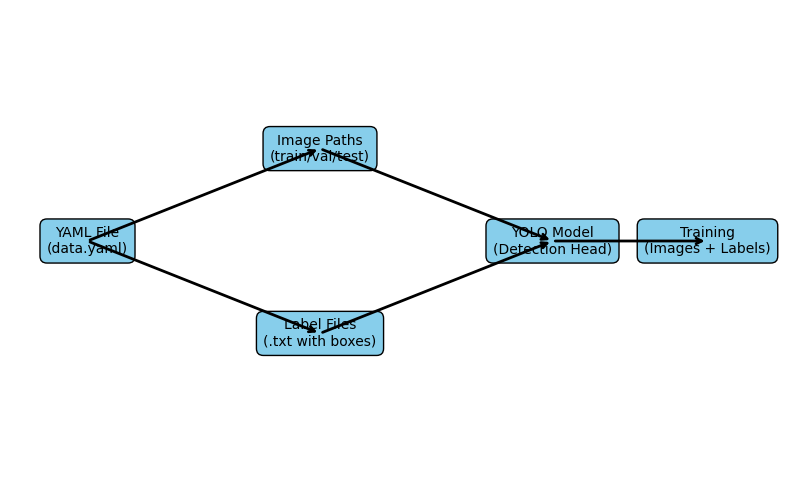

In [1]:
import matplotlib.pyplot as plt

# Create a diagram of how YOLO uses the YAML file for training
fig, ax = plt.subplots(figsize=(10,6))

# Diagram elements
elements = {
    "YAML File\n(data.yaml)": (0.1, 0.5),
    "Image Paths\n(train/val/test)": (0.4, 0.7),
    "Label Files\n(.txt with boxes)": (0.4, 0.3),
    "YOLO Model\n(Detection Head)": (0.7, 0.5),
    "Training\n(Images + Labels)": (0.9, 0.5)
}

# Draw boxes
for text, (x, y) in elements.items():
    ax.text(x, y, text, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor="skyblue", edgecolor="black"))

# Draw arrows
arrows = [
    ("YAML File\n(data.yaml)", "Image Paths\n(train/val/test)"),
    ("YAML File\n(data.yaml)", "Label Files\n(.txt with boxes)"),
    ("Image Paths\n(train/val/test)", "YOLO Model\n(Detection Head)"),
    ("Label Files\n(.txt with boxes)", "YOLO Model\n(Detection Head)"),
    ("YOLO Model\n(Detection Head)", "Training\n(Images + Labels)")
]

for start, end in arrows:
    x1, y1 = elements[start]
    x2, y2 = elements[end]
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=2))

ax.axis("off")
plt.show()
